In [ ]:
# 感情毎にvadとintencityで相関係数を算出
import pandas as pd

# OGVCの未加工データ(/home/mitani/vad-model_02.ipynbで作成した)
# /home/mitani/CSJ-emo-int_bunseki/0718/wagner_csj_vad/Wagner_OGVC_VAD.ipynbの結果と同じ(コピー済み)
df = pd.read_csv("/home/mitani/VA_results_bulk/OGVC_VAD_bulk.csv")       
df.head()

,utt_id,filename,valence,arousal,dominance,intensity,emotion
0,FOY0101,FOY0101ANT0.wav,0.343053,0.333032,0.417036,0,ANT
1,FOY0101,FOY0101ANT1.wav,0.358071,0.425703,0.479033,1,ANT
2,FOY0101,FOY0101ANT2.wav,0.449238,0.607365,0.616360,2,ANT
3,FOY0101,FOY0101ANT3.wav,0.427220,0.620275,0.616097,3,ANT
4,FOY0104,FOY0104FEA0.wav,0.337510,0.301136,0.398823,0,FEA


In [3]:
# ogvc
#感情強度と各VAD特徴量の相関係数を算出した結果、
#Arousal と強度の間に最も強い正の相関（r = 0.589）が見られた。
#次に Dominance が中程度の正の相関（r = 0.488）を示したが、
#Valence との相関は弱かった（r = 0.116）。
#これより、感情強度は主に覚醒度の変動によって説明されることが示唆された。

import pandas as pd

# csv 読み込み
df = pd.read_csv("/home/mitani/VA_results_bulk/OGVC_VAD_bulk.csv")

# 必要な列だけ選択
cols = ['valence', 'arousal', 'dominance', 'intensity']
df_sub = df[cols]

# ピアソン相関係数
corr = df_sub.corr(method='pearson').round(2)

# print(corr['intensity'])
print(corr)

           valence  arousal  dominance  intensity
valence       1.00     0.22       0.20       0.12
arousal       0.22     1.00       0.97       0.59
dominance     0.20     0.97       1.00       0.49
intensity     0.12     0.59       0.49       1.00


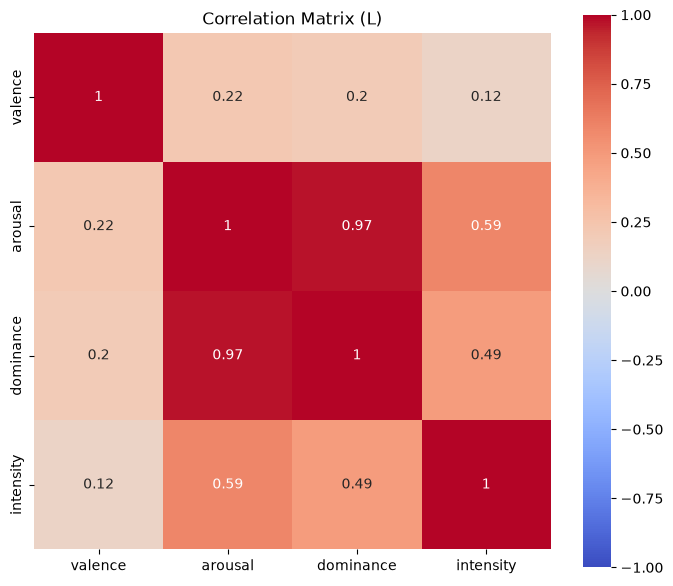

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sp = "L"

# ヒートマップ表示
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,      # 数値表示
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(f"Correlation Matrix ({sp})")
plt.tight_layout()
plt.show()

In [ ]:
# creama-d
import pandas as pd

# CSV 読み込み
df = pd.read_csv("CREMA_D_VAD_results/CREMA_D_VAD_results.csv")

# intensity を数値に変換
mapping = {"LO": 0, "MD": 1, "HI": 2}
df["intensity_numeric"] = df["intensity"].map(mapping)

# print(df[["intensity", "intensity_numeric"]].head())

df_sub = df[['valence', 'arousal', 'dominance', 'intensity_numeric']]
print(df_sub.corr(method='pearson'))

                    valence   arousal  dominance  intensity_numeric
valence            1.000000  0.404042   0.401645           0.075883
arousal            0.404042  1.000000   0.990200           0.428093
dominance          0.401645  0.990200   1.000000           0.408446
intensity_numeric  0.075883  0.428093   0.408446           1.000000


In [ ]:
# 各感情における, 感情次元ベクトルとintensityの相関を求める
# OGVC_VAD_corrmatrixに保存

import pandas as pd
import os

# === 入力CSV ===
csv_path = "VA_results_bulk/OGVC_VAD_bulk.csv"
df = pd.read_csv(csv_path)

# === 相関をとる4変数 ===
cols = ["valence", "arousal", "dominance", "intensity"]

# === emotion 一覧 ===
emotions = df["emotion"].unique()

# === 出力フォルダ ===
out_dir = "OGVC_VAD_corrmatrix"
os.makedirs(out_dir, exist_ok=True)

for emotion in emotions:
    subset = df[df["emotion"] == emotion]

    # 相関行列（4×4）
    corr_matrix = subset[cols].corr()

    # CSV 保存
    corr_matrix.to_csv(f"{out_dir}/{emotion}_corrmatrix.csv")

    print(f"保存完了 → {out_dir}/{emotion}_corrmatrix.csv")

print("🎉 全emotionの相関行列を保存しました。")

保存完了 → OGVC_VAD_corrmatrix/ANT_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/FEA_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/SUR_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/SAD_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/ANG_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/ACC_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/DIS_corrmatrix.csv
保存完了 → OGVC_VAD_corrmatrix/JOY_corrmatrix.csv
🎉 全emotionの相関行列を保存しました。


In [3]:
# 上記+ヒートマップ表示 をまとめた完全版
import pandas as pd
import matplotlib.pyplot as plt
import os

# === CSV 読み込み ===
df = pd.read_csv("VA_results_bulk/OGVC_VAD_bulk.csv")

# === 相関をとる4変数 ===
cols = ["valence", "arousal", "dominance", "intensity"]

# === emotion 一覧 ===
emotions = df["emotion"].unique()

# === 出力フォルダ ===
out_dir = "OGVC_VAD_corr_heatmaps"
os.makedirs(out_dir, exist_ok=True)

for emotion in emotions:
    subset = df[df["emotion"] == emotion]

    # --- 相関行列（4×4） ---
    corr_matrix = subset[cols].corr()

    # --- 相関行列をCSVで保存 ---
    corr_matrix.to_csv(f"{out_dir}/{emotion}_corrmatrix.csv")

    # --- Heatmap プロット ---
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_matrix, interpolation="nearest")
    plt.title(f"Correlation Heatmap: {emotion}")
    plt.xticks(range(len(cols)), cols, rotation=45)
    plt.yticks(range(len(cols)), cols)
    plt.colorbar()
    plt.tight_layout()

    # 画像保存
    plt.savefig(f"{out_dir}/{emotion}_heatmap.png")
    plt.close()

print("🎉 全感情の相関行列とヒートマップの生成が完了しました。")
print(f"📁 出力フォルダ: {out_dir}")

🎉 全感情の相関行列とヒートマップの生成が完了しました。
📁 出力フォルダ: OGVC_VAD_corr_heatmaps


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# === CSV 読み込み ===
df = pd.read_csv("VA_results_bulk/OGVC_VAD_bulk.csv")

# === 相関をとる4変数 ===
cols = ["valence", "arousal", "dominance", "intensity"]

# === emotion 一覧 ===
emotions = df["emotion"].unique()

# === 出力フォルダ ===
out_dir = "OGVC_VAD_corr_heatmaps"
os.makedirs(out_dir, exist_ok=True)


for emotion in emotions:
    subset = df[df["emotion"] == emotion]

    # --- 相関行列（4×4） ---
    corr_matrix = subset[cols].corr()

    # CSV 保存
    corr_matrix.to_csv(f"{out_dir}/{emotion}_corrmatrix.csv")

    # --- Heatmap プロット ---
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_matrix, cmap="Blues", vmin=-1, vmax=1)

    plt.title(f"Correlation Heatmap: {emotion}")
    plt.xticks(range(len(cols)), cols, rotation=45)
    plt.yticks(range(len(cols)), cols)

    # カラーバー
    plt.colorbar()

    # --- 各マスに相関係数を描画 ---
    for i in range(len(cols)):
        for j in range(len(cols)):
            value = corr_matrix.iloc[i, j]
            plt.text(
                j, i, f"{value:.2f}",
                ha="center", va="center", color="black", fontsize=10
            )

    plt.tight_layout()

    # 保存
    plt.savefig(f"{out_dir}/{emotion}_heatmap.png", dpi=300)
    plt.close()

print("🎉 色付き & 数値表示ヒートマップの生成が完了しました！")


🎉 色付き & 数値表示ヒートマップの生成が完了しました！


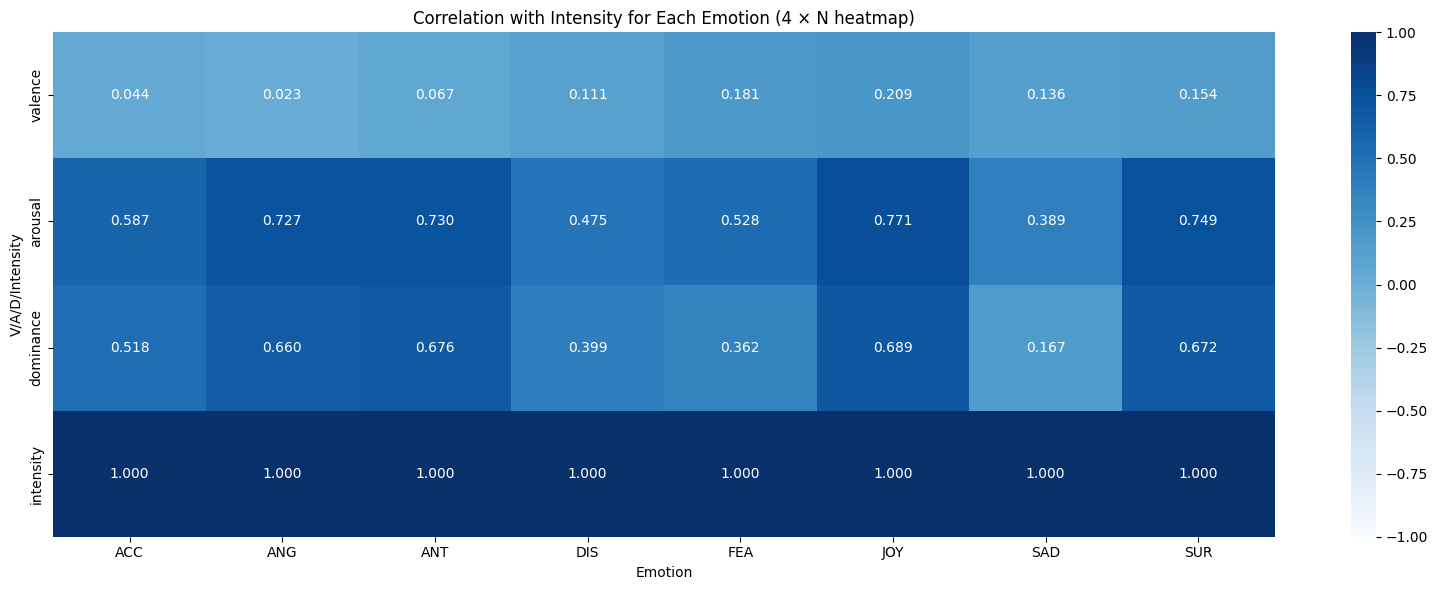

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV読み込み（あなたの環境でパスは調整してOK）
df = pd.read_csv("VA_results_bulk/OGVC_VAD_bulk.csv")

# emotion一覧（CSVに含まれているものを自動抽出）
emotions = sorted(df["emotion"].unique())

# 最終結果を格納する 4×N のデータフレーム
result_matrix = pd.DataFrame(index=["valence", "arousal", "dominance", "intensity"],
                             columns=emotions)

# 各感情ごとに相関（Intensity との相関）を計算して横に並べる
for emo in emotions:
    sub = df[df["emotion"] == emo]

    # intensity との相関を取得
    corr_val = sub[["valence", "arousal", "dominance", "intensity"]].corr()

    # 4×1 だが、まとめて1列に入れる
    result_matrix[emo] = corr_val["intensity"]

# ---- ヒートマップ描画 ----

plt.figure(figsize=(2*len(emotions), 6))  # 横長に
sns.heatmap(
    result_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlation with Intensity for Each Emotion (4 × N heatmap)")
plt.xlabel("Emotion")
plt.ylabel("V/A/D/Intensity")
plt.tight_layout()
plt.show()

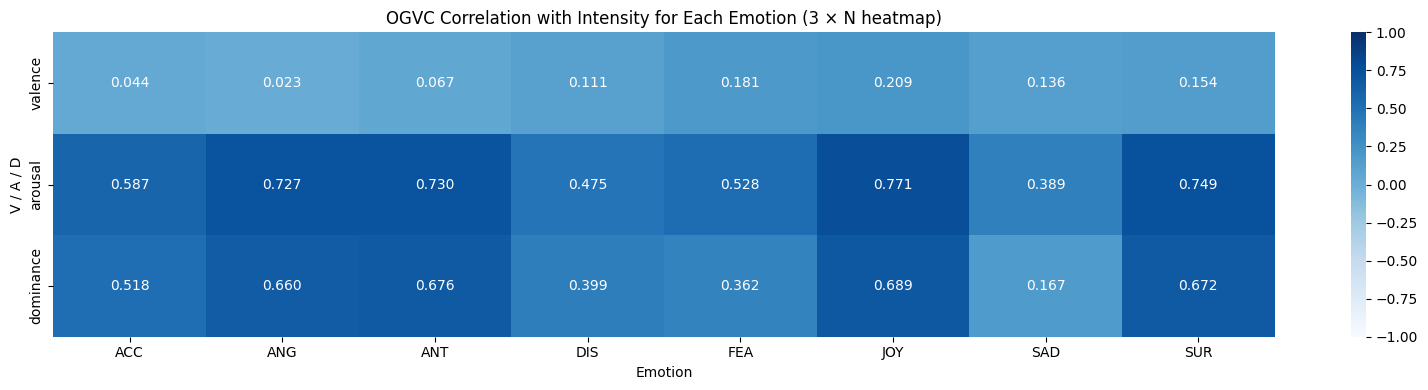

In [ ]:
# 完全版

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV読み込み（適宜パス変更）
df = pd.read_csv("VA_results_bulk/OGVC_VAD_bulk.csv")

# emotion一覧を取得
emotions = sorted(df["emotion"].unique())

# 最終結果：3×N（valence/arousal/dominance × emotion）
result_matrix = pd.DataFrame(index=["valence", "arousal", "dominance"],
                             columns=emotions)

# 各感情ごとに intensity との相関を計算して列に追加
for emo in emotions:
    sub = df[df["emotion"] == emo]
    corr_val = sub[["valence", "arousal", "dominance", "intensity"]].corr()

    # intensity との相関（valence, arousal, dominance の3つ）
    result_matrix[emo] = corr_val.loc["valence":"dominance", "intensity"]

# ---- ヒートマップ描画 ----

plt.figure(figsize=(2 * len(emotions), 4))
sns.heatmap(
    result_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("OGVC Correlation with Intensity for Each Emotion (3 × N heatmap)")
plt.xlabel("Emotion")
plt.ylabel("V / A / D")
plt.tight_layout()
plt.show()

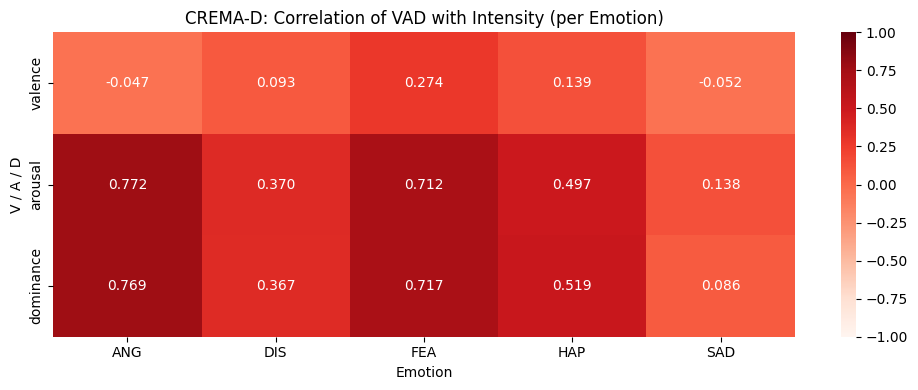

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === CSV読み込み ===
df = pd.read_csv("CREMA_D_VAD_results/CREMA_D_VAD_results.csv")

# === intensity を数値に変換 ===
mapping = {"LO": 0, "MD": 1, "HI": 2}
df["intensity"] = df["intensity"].map(mapping)

# === emotion 一覧 ===
emotions = sorted(df["emotion"].unique())

# === 相関格納用（3 × N） ===
result_matrix = pd.DataFrame(
    index=["valence", "arousal", "dominance"],
    columns=emotions
)

# === 各 emotion の valence/arousal/dominance と intensity の相関を計算 ===
for emo in emotions:
    sub = df[df["emotion"] == emo]

    # 4変数の相関行列を作る
    corr = sub[["valence", "arousal", "dominance", "intensity"]].corr()

    # intensity との相関だけ抜き出して列に追加 (valence〜dominance)
    result_matrix[emo] = corr.loc["valence":"dominance", "intensity"]

# === まとめヒートマップ描画（縦3 × 横N） ===
plt.figure(figsize=(2 * len(emotions), 4))

sns.heatmap(
    result_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="Reds",
    vmin=-1,
    vmax=1
)

plt.title("CREMA-D: Correlation of VAD with Intensity (per Emotion)")
plt.xlabel("Emotion")
plt.ylabel("V / A / D")

plt.tight_layout()
plt.show()